# Intro to qiskit

[qiskit](https://es.wikipedia.org/wiki/Qiskit)

Qiskit is a software development kit created by `IBM` for working with quantum computers at the circuit, pulse, and algorithm levels. It provides tools for creating and manipulating quantum programs and **running them on prototype quantum devices in IBM Quantum Experience or on simulators on a local computer**. It follows the circuit model for universal quantum computing and can be used for any quantum hardware (currently supporting superconducting qubits and trapped ions ) that follows this model.

* The main version of Qiskit uses the `Python`: pip install qiskit qiskit_aer pylatexenc
* Qiskit allows users to easily design experiments and applications and run them on real quantum computers and/or classical simulators.

## install and run
* pip install qiskit
* pip install qiskit_aer
* pylatexenc
It is on virtual enviroment (.ven)

In [2]:
import qiskit
qiskit.__version__ 

'2.4.1'

## What is a quantum circuit?

[see qc](https://quantum.cloud.ibm.com/docs/en/guides/construct-circuits)
A simple quantum circuit is a collection of qubits and a list of instructions that act on those qubits. 

### Single-Qubit gates

1. Pauli gates
X: bit-flip gate

In [2]:
from qiskit import QuantumCircuit
qc = QuantumCircuit(2)
qc.x(0)
qc.draw()

┌───┐
q_0: ┤ X ├
     └───┘
q_1: ─────

**Example** To demonstrate, the following cell creates a new circuit with two new qubits, then displays the circuit's qubits attribute, which is a list of Qubit

In [8]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3)
qc.qubits

[<Qubit register=(3, "q"), index=0>,
 <Qubit register=(3, "q"), index=1>,
 <Qubit register=(3, "q"), index=2>]

Multiple QuantumRegister and ClassicalRegister objects can be combined to create a circuit. Every `QuantumRegister` and `ClassicalRegister` can also be named.

In [9]:
from qiskit.circuit import QuantumRegister, ClassicalRegister

qr1 = QuantumRegister(2, "qreg1")  # Create a QuantumRegister with 2 qubits
qr2 = QuantumRegister(1, "qreg2")  # Create a QuantumRegister with 1 qubit
cr1 = ClassicalRegister(3, "creg1")  # Create a ClassicalRegister with 3 cbits

combined_circ = QuantumCircuit(
    qr1, qr2, cr1
)  # Create a quantum circuit with 2 QuantumRegisters and 1 ClassicalRegister
combined_circ.qubits

[<Qubit register=(2, "qreg1"), index=0>,
 <Qubit register=(2, "qreg1"), index=1>,
 <Qubit register=(1, "qreg2"), index=0>]

You can find a qubit's index and register by using the circuit's `find_bit` method and its attributes.

In [10]:
desired_qubit = qr2[0]  # Qubit 0 of register 'qreg2'

print("Index:", combined_circ.find_bit(desired_qubit).index)
print("Register:", combined_circ.find_bit(desired_qubit).registers)

Index: 2
Register: [(QuantumRegister(1, 'qreg2'), 0)]


Adding an instruction to the circuit appends the instruction to the circuit's `data` attribute. The following cell output shows data is a list of `CircuitInstruction` objects, each of which has an operation attribute, and a qubits attribute.

In [11]:
qc.x(0)  # Add X-gate to qubit 0
qc.data

[CircuitInstruction(operation=Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>,), clbits=())]

The easiest way to view this information is through the `draw` method, which returns a visualization of a circuit. See `Visualize circuits` for different ways of displaying quantum circuits.

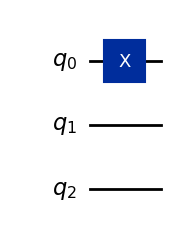

In [12]:
qc.draw("mpl")

In [13]:
qc = QuantumCircuit(1)
qc.x(0)
qc.draw()

┌───┐
q: ┤ X ├
   └───┘

## Build circuit

To combine two circuits, use the compose method. This accepts another QuantumCircuit and an optional list of qubit mappings.

The `compose` method returns a new circuit and does not mutate either circuit it acts on. To mutate the circuit on which you're calling the compose method, use the argument inplace=True.

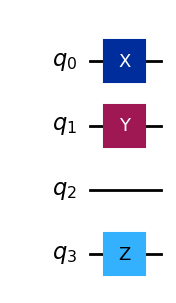

In [14]:
qc_a = QuantumCircuit(4)
qc_a.x(0)

qc_b = QuantumCircuit(2, name="qc_b")
qc_b.y(0)
qc_b.z(1)

# compose qubits (0, 1) of qc_a to qubits (1, 3) of qc_b respectively
combined = qc_a.compose(qc_b, qubits=[1, 3])
combined.draw("mpl")

... see IBM documentation

## Measure qubits

Measurements are used to sample the states of individual qubits and transfer the results to a classical register. Note that if you are submitting circuits to a Sampler primitive, measurements are required. However, circuits submitted to an Estimator primitive must not contain measurements.

Qubits can be measured using three methods: **measure, measure_all** and **measure_active**.

1. **QuantumCircuit.measure**: measures each qubit in the first argument onto the classical bit given as the second argument. This method allows full control over where the measurement result is stored.
2. **QuantumCircuit.measure_all**: takes no argument and can be used for quantum circuits without pre-defined classical bits. It creates classical wires and stores measurement results in order. For example, measurement of qubit $q_i$  is stored in cbit 
$meas_i$. It also adds a barrier before the measurement.
3. **QuantumCircuit.measure_active**: similar to measure_all, but measures only qubits that have operations.

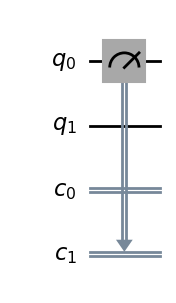

In [15]:
qc1 = QuantumCircuit(2, 2)
qc1.measure(0, 1)
qc1.draw("mpl", cregbundle=False)

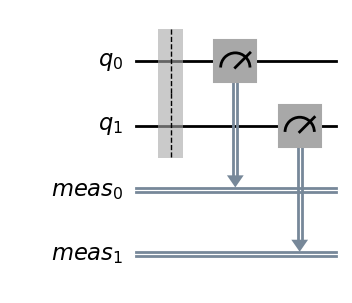

In [16]:
qc2 = QuantumCircuit(2)
qc2.measure_all()
qc2.draw("mpl", cregbundle=False)

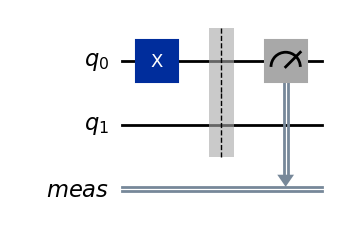

In [17]:
qc3 = QuantumCircuit(2)
qc3.x(0)
qc3.measure_active()
qc3.draw("mpl", cregbundle=False)


## Funcionality

**1. Qiskit Terra**

* The Terra element is the foundation upon which the rest of Qiskit is built. 
* .. provides tools for **creating quantum circuits** at or near the quantum machine code level. 
* It allows processes running on quantum hardware to be explicitly constructed in terms of quantum gates
* ... managing batches of jobs and running them on remotely accessible quantum simulators and devices.

**Example:** It creates a quantum circuit for two qubits, consisting of the quantum gates needed to create a `Bell state`  (two entangled qubits). The quantum circuit then terminates with quantum measurements, extracting one bit from each qubit.

In [3]:
import qiskit
qiskit.__version__ 

'2.4.1'

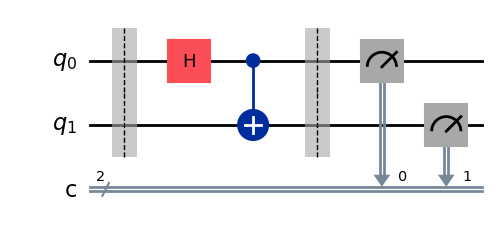

In [14]:
# Othere example to plot the circuit: IBM manual
from qiskit import QuantumCircuit

q_bell = QuantumCircuit(2,2)
q_bell.barrier()
q_bell.h(0)
q_bell.cx(0,1)
q_bell.barrier()
q_bell.measure([0,1],[0,1]) # Measure qubits 0 and 1 into classical bits 0 and 1 (second[0,1] is the classical register)

q_bell.draw(output='mpl',plot_barriers=True)

**2. Qiskit Aer**

The Aer component provides high-performance **quantum computing simulators** with realistic noise models. 

It offers simulators hosted **locally** on the user's device, as well as HPC resources available via the **cloud**. The simulators can also simulate the effects of noise for both simple and sophisticated noise models.

Once the quantum circuit has been created, it can be run on a **backend** (either quantum hardware or a simulator). 

**Backends** represent either a simulator or a real quantum computer, and are responsible for running quantum circuits and returning results. They take in a qobj as input, which is a quantum object and the result of the compilation process, and they return a BaseJob object.

{'11': 492, '00': 508}


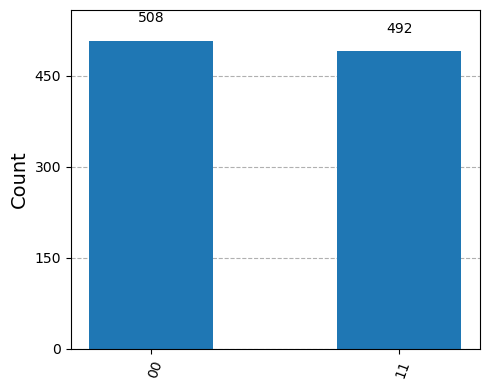

In [17]:
# 1. Update your imports
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer  # Se ha cambiado de qiskit import Aer a qiskit_aer import Aer. IBM corretion
from qiskit.visualization import plot_histogram

# 2. Set up your backend
backend = Aer.get_backend('qasm_simulator') # locally

# 3. Transpile the circuit for your specific backend. transport compilation
compiled_circuit = transpile(q_bell, backend)

# 4. Run the circuit using the backend's run method.
job = backend.run(compiled_circuit, shots=1000) # shots: number of times to run the circuit

result_sim = job.result()

print(result_sim.get_counts(q_bell))
plot_histogram(result_sim.get_counts(q_bell),figsize=(5,4))

The final statement will show the **results returned by the backend**. This is a `Python dictionary` that describes the bit strings obtained from multiple executions of the quantum circuit. In the quantum circuit used in this example, the bit strings `x` '00'and `y` '11'should be the only possible outcomes and should occur with equal probability.

**Exercise:** Try changing the code to see how it affects the results. For example:

1. Add a third qubit by changing to QuantumCircuit(3), and add a second CX gate with qc.cx(1,2). The measurements should then change to 000 and 111, which means all three of these qubits have been entangled.

2. See your results shift by adding qc.x(1) to the end of the circuit.

# Deutsch-Jozsa 

[see section 13:](https://www.tsc.uc3m.es/~gvazquez/intro-cuantica/13-algoritmos.html)

[quantum.cloud.ibm.com](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)


.. in process